# Validación y análisis exploratorio del dataset

Ejecuta `scripts/eda.py` y analiza su resultado (`reports/eda/dataset_report.json` + figuras).
Responde: ¿el dataset está sano? ¿hay fuga entre particiones? ¿qué clases están desbalanceadas? ¿las anotaciones están completas?

> Requisito: dataset en `src/data/kaggle_dataset/` (ver `docs/DATASET.md`). Ejecuta las celdas en orden.

In [1]:
import sys
from pathlib import Path

_nb = Path.cwd() if (Path.cwd() / "helpers.py").exists() else Path.cwd() / "notebooks"
sys.path.insert(0, str(_nb))
from helpers import *   # utilidades compartidas (pd, plt, np, run, read_json, show_images...)

REPO = setup()          # cambia el directorio de trabajo a la raíz del repo
print("Repositorio:", REPO)

Repositorio: /home/usuario/Code/Projects/Computer Vision Projects/PPE-detection-using-computer-vision


In [2]:
DATASET_ROOT  = env("DATASET_ROOT", "src/data/kaggle_dataset")
EDA_DIR       = env("EDA_DIR", "reports/eda")
RUN_EDA       = True    # False: reutiliza el dataset_report.json existente
SKIP_NEAR_DUP = False   # True acelera datasets muy grandes (omite duplicados perceptuales)

In [4]:
report_path = Path(EDA_DIR) / "dataset_report.json"
if RUN_EDA or not report_path.exists():
    cmd = [sys.executable, "src/eda.py", "--root", DATASET_ROOT, "--out", EDA_DIR]
    if SKIP_NEAR_DUP:
        cmd.append("--skip-near-dup")
    run(cmd)
report = read_json(report_path)
print("Clases:", report["dataset"]["classes"])

$ /home/usuario/Code/Projects/Computer Vision Projects/PPE-detection-using-computer-vision/.venv/bin/python src/eda.py --root src/data/kaggle_dataset --out reports/eda
2026-10-09 16:30:37,023 INFO YAML: /home/usuario/Code/Projects/Computer Vision Projects/PPE-detection-using-computer-vision/src/data/kaggle_dataset/data.yaml | clases (5): ['helmet', 'no_helmet', 'no_vest', 'person', 'vest']
2026-10-09 16:30:37,023 INFO Particiones: {'train': '/home/usuario/Code/Projects/Computer Vision Projects/PPE-detection-using-computer-vision/src/data/kaggle_dataset/train/images', 'val': '/home/usuario/Code/Projects/Computer Vision Projects/PPE-detection-using-computer-vision/src/data/kaggle_dataset/valid/images', 'test': '/home/usuario/Code/Projects/Computer Vision Projects/PPE-detection-using-computer-vision/src/data/kaggle_dataset/test/images'}
2026-10-09 16:30:43,904 INFO [train] 1000/3248 imágenes
2026-10-09 16:30:50,892 INFO [train] 2000/3248 imágenes
2026-10-09 16:30:57,296 INFO [train] 3000/

## 1. Resumen por partición

In [5]:
splits = report["splits"]
summary = pd.DataFrame({
    s: {"imágenes": v["n_images"], "legibles": v["n_readable"], "objetos": v["n_objects"],
        "objetos/imagen (media)": round(v["boxes_per_image"].get("mean", 0), 2),
        "objetos pequeños %": round(v["small_objects_pct"] or 0, 1),
        "resoluciones únicas": v["resolutions"]["unique"]}
    for s, v in splits.items()}).T
summary["% de imágenes"] = pd.Series(report["totals"]["split_share_pct"])
display(summary)

,imágenes,legibles,objetos,objetos/imagen (media),objetos pequeños %,resoluciones únicas,% de imágenes
train,3248.0,3248.0,24184.0,7.45,21.7,1.0,80.0
val,406.0,406.0,3095.0,7.62,17.2,1.0,10.0
test,406.0,406.0,2785.0,6.86,20.2,1.0,10.0


## 2. Objetos por clase y desbalance

In [6]:
per_class = pd.DataFrame({s: v["objects_per_class"] for s, v in splits.items()})
per_class["total"] = per_class.sum(axis=1)
per_class["% del total"] = (100 * per_class["total"] / per_class["total"].sum()).round(2)
display(per_class)
imb = report["imbalance"]
print("Razón máx/mín entre clases:", None if imb["max_min_ratio"] is None else round(imb["max_min_ratio"], 1))
print("Clases sin objetos:", imb["classes_without_objects"] or "ninguna")

,train,val,test,total,% del total
helmet,4068,531,529,5128,17.06
no_helmet,3993,523,393,4909,16.33
no_vest,4912,649,513,6074,20.20
person,8259,1042,954,10255,34.11
vest,2952,350,396,3698,12.30


Razón máx/mín entre clases: 2.8
Clases sin objetos: ninguna


## 3. Integridad: archivos y etiquetas

In [7]:
rows = []
for s, v in splits.items():
    rows.append({"partición": s, "corruptas": v["corrupt_images"]["count"],
                 "sin etiqueta": v["images_without_label_file"]["count"],
                 "etiquetas huérfanas": v["orphan_label_files"]["count"],
                 "etiquetas vacías": v["images_with_empty_label"]["count"],
                 **{k: x["count"] for k, x in v["label_issues"].items()}})
issues = pd.DataFrame(rows).set_index("partición").fillna(0).astype(int)
display(issues)
print("Total de problemas (sin contar etiquetas vacías, que son fondo válido):",
      int(issues.drop(columns="etiquetas vacías").to_numpy().sum()))

,corruptas,sin etiqueta,etiquetas huérfanas,etiquetas vacías
partición,,,,
train,0,0,0,0
val,0,0,0,0
test,0,0,0,0


Total de problemas (sin contar etiquetas vacías, que son fondo válido): 0


## 4. Duplicados y fuga de información entre particiones

In [8]:
d = report["duplicates"]
print("Grupos de duplicados exactos:", d["exact_duplicate_groups"]["count"])
print("Duplicados exactos entre particiones:", d["exact_duplicates_across_splits"]["count"])
print("Misma imagen fuente (Roboflow) en particiones distintas:", d["same_source_across_splits_roboflow"]["count"])
nd = d["near_duplicates"]
if nd:
    print(f"Casi-duplicados (Hamming <= {nd['hamming_threshold']}): {nd['clusters']} grupos; "
          f"{nd['clusters_across_splits']} cruzan particiones; "
          f"{nd['val_test_images_with_train_twin']} imágenes de val/test tienen un gemelo en train")
for ex in d["exact_duplicates_across_splits"]["examples"][:3]:
    print(" ejemplo:", [(e["split"], Path(e["path"]).name) for e in ex])

Grupos de duplicados exactos: 0
Duplicados exactos entre particiones: 0
Misma imagen fuente (Roboflow) en particiones distintas: 24
Casi-duplicados (Hamming <= 2): 88 grupos; 52 cruzan particiones; 72 imágenes de val/test tienen un gemelo en train


## 5. Recomendaciones automáticas

In [9]:
for r in report["recommendations"] or ["Sin hallazgos que requieran acción."]:
    print("-", r)

- Posible fuga de información entre particiones: volver a dividir agrupando por imagen fuente.


## 6. Visualizaciones generadas

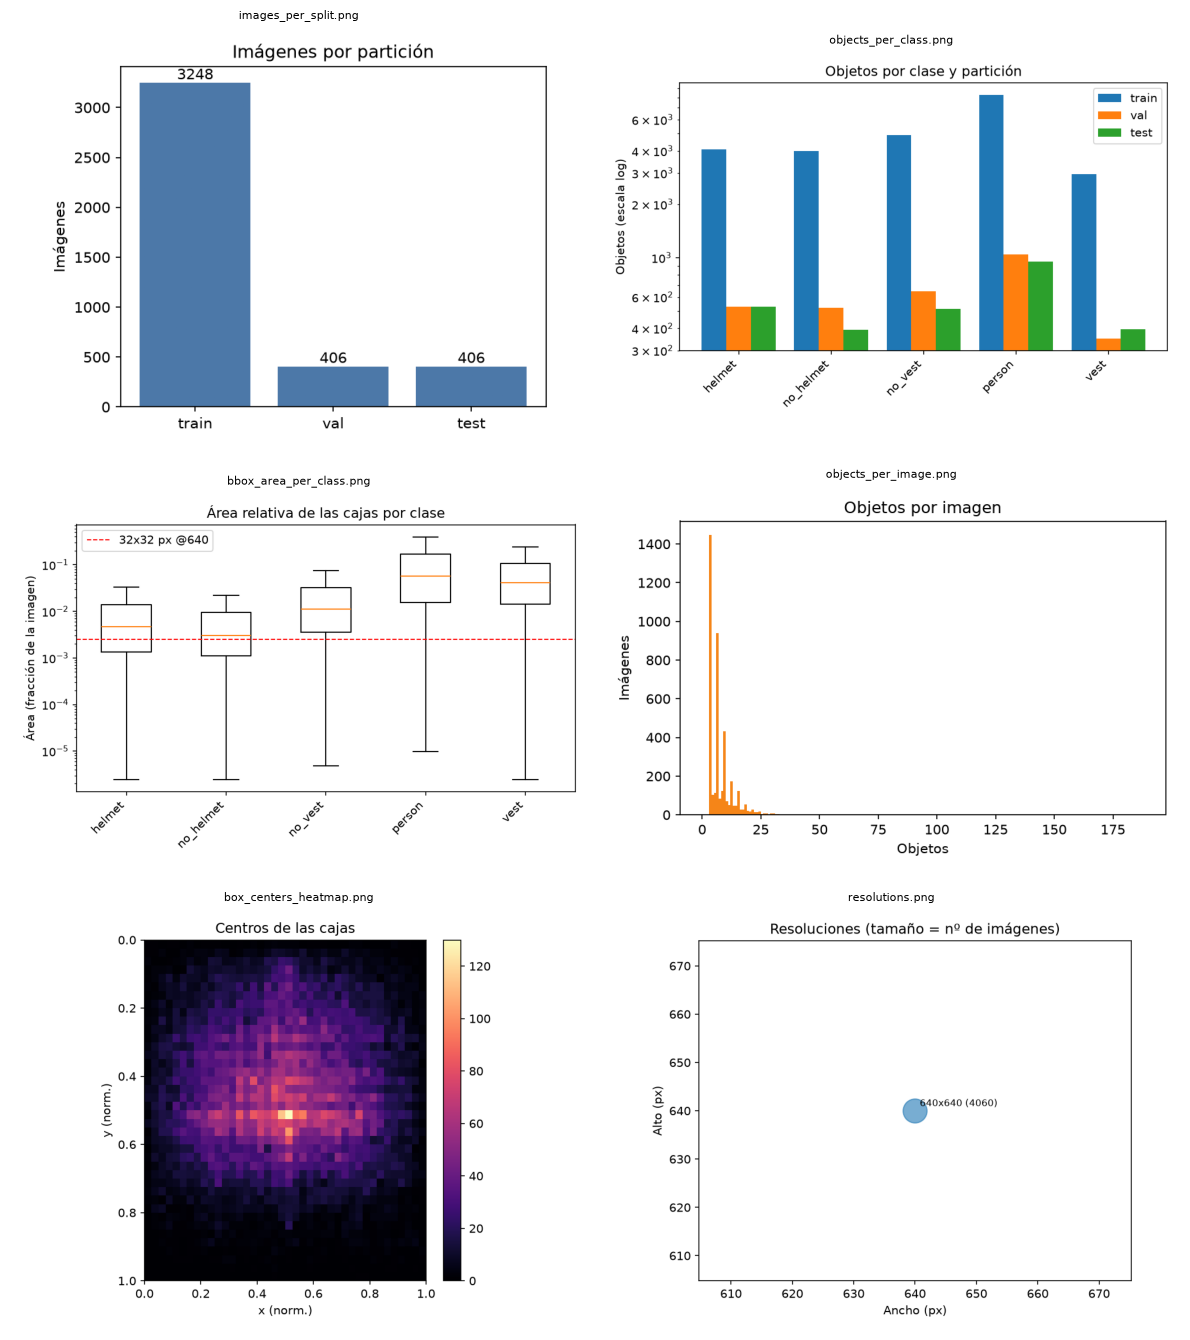

In [10]:
figs = ["images_per_split", "objects_per_class", "bbox_area_per_class", "objects_per_image", "box_centers_heatmap", "resolutions"]
show_images([Path(EDA_DIR) / f"{f}.png" for f in figs], cols=2, size=(6, 4.5))

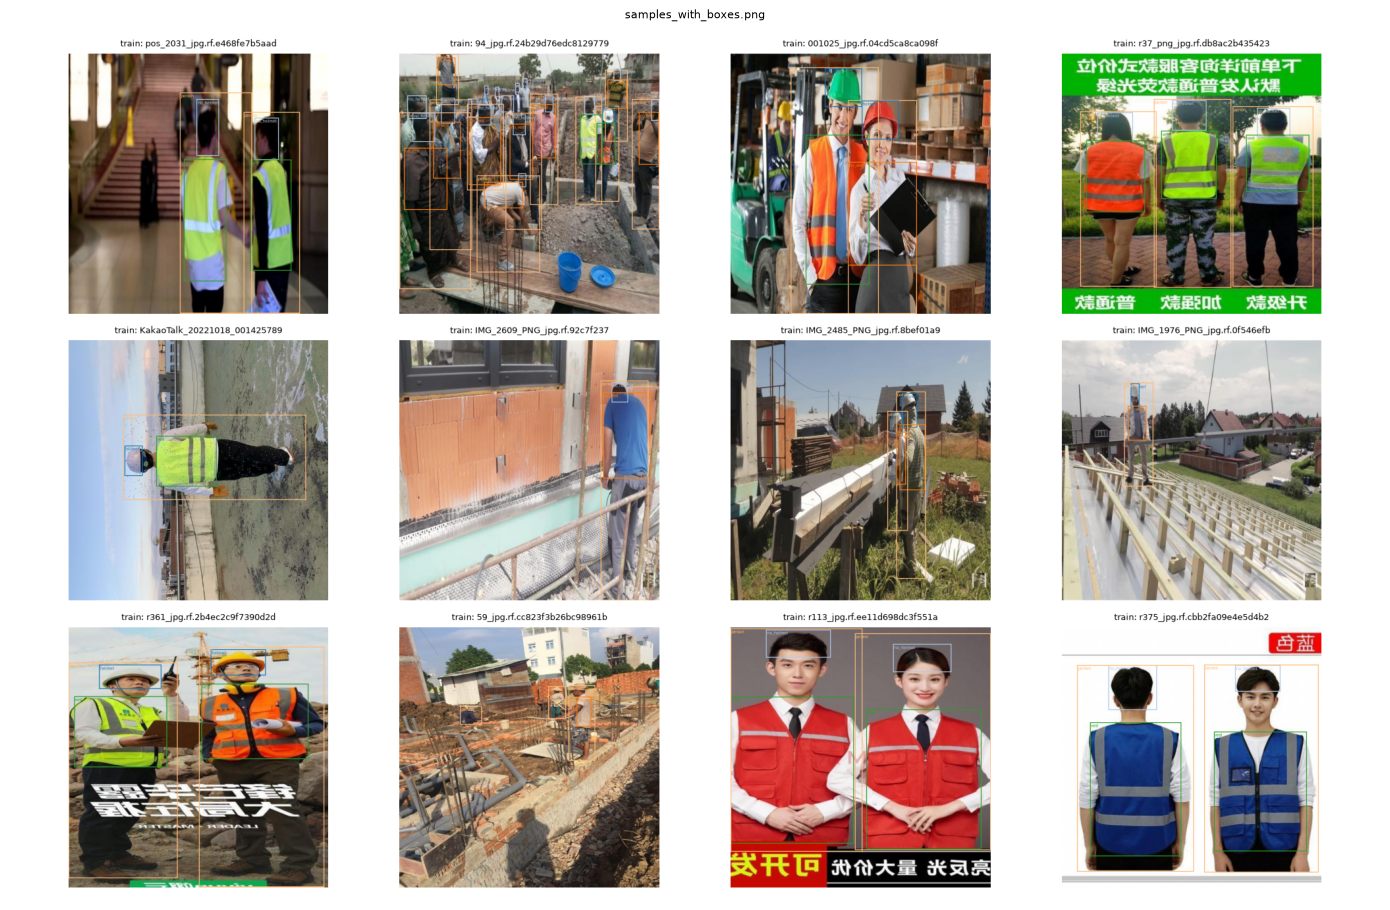

In [11]:
show_images([Path(EDA_DIR) / "samples_with_boxes.png"], cols=1, size=(14, 10))

## 7. Análisis adicional: ¿las anotaciones de EPP están completas?

Si en muchas imágenes hay más `person` que cabezas anotadas (`helmet` + `no_helmet`), el dataset no etiqueta todas las cabezas.
Eso afecta la **estrategia de decisión**: con `association` se generarían falsas alarmas; con `explicit` se perderían incumplimientos.

In [12]:
import yaml
from ppe.data.dataset import (class_names, find_data_yaml, label_path_for, labels_dir_for, list_images,
                              parse_label_file, resolve_splits)

root = Path(DATASET_ROOT).resolve()
ypath = find_data_yaml(root)
cfg = yaml.safe_load(ypath.read_text(encoding="utf-8"))
names = class_names(cfg)
rows = []
for split, img_dir in resolve_splits(root, ypath, cfg).items():
    lbl = labels_dir_for(img_dir)
    for p in list_images(img_dir):
        lp = label_path_for(p, img_dir, lbl)
        if not lp.exists():
            continue
        boxes, _ = parse_label_file(lp, len(names))
        cnt = {n: 0 for n in names}
        for c, *_ in boxes:
            if 0 <= c < len(names):
                cnt[names[c]] += 1
        rows.append({"split": split, "image": p.name, **cnt})
df = pd.DataFrame(rows)
for col in ("person", "helmet", "no_helmet", "vest", "no_vest"):
    if col not in df:
        df[col] = 0
df["cabezas_anotadas"] = df["helmet"] + df["no_helmet"]
df["torsos_anotados"] = df["vest"] + df["no_vest"]
df["personas_sin_cabeza"] = (df["person"] - df["cabezas_anotadas"]).clip(lower=0)
df["personas_sin_torso"] = (df["person"] - df["torsos_anotados"]).clip(lower=0)
cover = df.groupby("split").agg(
    imagenes=("image", "count"), personas=("person", "sum"),
    cabezas_anotadas=("cabezas_anotadas", "sum"), torsos_anotados=("torsos_anotados", "sum"),
    pct_imagenes_con_personas_sin_cabeza=("personas_sin_cabeza", lambda s: round(100 * (s > 0).mean(), 1)),
    pct_imagenes_con_personas_sin_torso=("personas_sin_torso", lambda s: round(100 * (s > 0).mean(), 1)))
display(cover)

,imagenes,personas,cabezas_anotadas,torsos_anotados,pct_imagenes_con_personas_sin_cabeza,pct_imagenes_con_personas_sin_torso
split,,,,,,
test,406,954,922,909,9.4,8.9
train,3248,8259,8061,7864,11.0,10.8
val,406,1042,1054,999,9.4,9.9


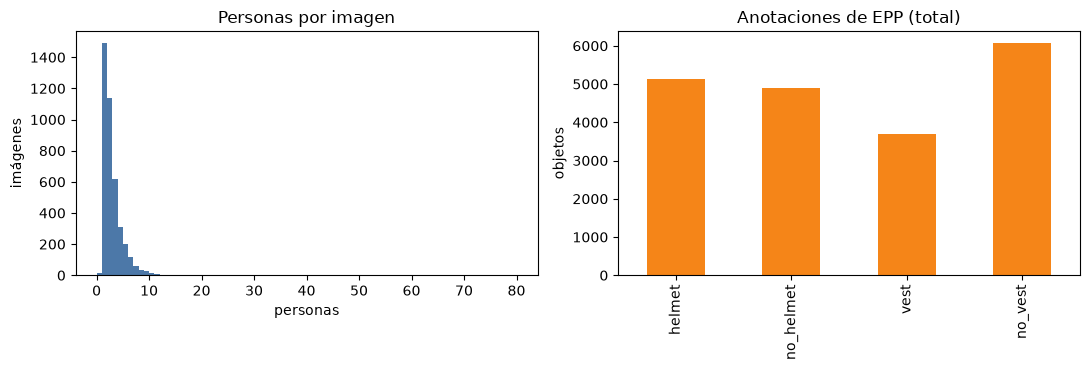

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
df["person"].plot.hist(bins=range(0, int(df["person"].max()) + 2), ax=ax[0], color="#4C78A8")
ax[0].set(title="Personas por imagen", xlabel="personas", ylabel="imágenes")
(df[["helmet", "no_helmet", "vest", "no_vest"]].sum()).plot.bar(ax=ax[1], color="#F58518")
ax[1].set(title="Anotaciones de EPP (total)", ylabel="objetos")
plt.tight_layout(); plt.show()

## 8. Hallazgos (completar para el reporte, sección 2)

| Tema | Hallazgo | Acción |
|---|---|---|
| Tamaño y particiones | _<>_ | _<>_ |
| Desbalance de clases | _<>_ | _<>_ |
| Objetos pequeños (cascos) | _<>_ | _<sugerir `imgsz` mayor / evaluar por clase>_ |
| Duplicados / fuga | _<>_ | _<>_ |
| Completitud de anotaciones | _<>_ | _<elegir estrategia de decisión>_ |